# Earthquake Disruption Analysis

## Findings

By training the model on data prior to the April 2016 Earthquake and then testing the model on data from two weeks before up until a month after the earthquake, we find that the model shows a large gap between the predicted and actual values on the test set. 

- The WAPE is just below 20% before the earthquake, then increases to 30% in the days just around the quake before dropping down to just above 20% after the earthquake. 
- Coastal regions, who were hit hardest by the earthquake, show a higher WAPE at 37% compared to the inland region's 29%. 
- Product families like home appliances, electronics and baby care show the highest excess demand ratios. This is plausible given that during an earthquake things often break or are damaged within houses, so many people may need to purchase new home appliances or items that may have been damaged during the quake. However, we also know from previous EDA that these are generally low volume units, so I also looked at the difference in true versus predicted values by total units, which shows that gorcery, beverages, produce and cleaning were among the families with the highest excess demand in total units, which makes sense after an earthquake that emergency essentials like this would have excess demand compared to that which is forecasted.

## Imports

In [1]:
import sys; sys.path.append("..")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from src.features import build_holiday_lookup
from src.training import build_features, CATEGORICAL
from src.models import train_lgbm
from src.evaluate import rmsle, wape

In [2]:
train = pd.read_parquet("../data/processed/train.parquet")
stores = pd.read_parquet("../data/processed/stores.parquet")
oil = pd.read_parquet("../data/processed/oil.parquet")
holidays = pd.read_parquet("../data/processed/holidays.parquet")

## Build Features

In [3]:
national, local = build_holiday_lookup(holidays)
feats = build_features(train.copy(), stores, oil, national, local)

for c in CATEGORICAL:
    feats[c] = feats[c].astype("category")

QUAKE = pd.Timestamp("2016-04-16")

## Train Model

In [4]:
train_cutoff = QUAKE - pd.Timedelta(days=16)
test_start = QUAKE - pd.Timedelta(days=14)
test_end = QUAKE + pd.Timedelta(days=42)

feature_cols = [c for c in feats.columns if c not in {"id", "date", "sales", "store_nbr"}]
fit = feats[feats["date"] <= train_cutoff]
test = feats[(feats["date"] >= test_start) & (feats["date"] <= test_end)]

model = train_lgbm(fit[feature_cols], np.log1p(fit["sales"].clip(lower=0)), categorical=CATEGORICAL, num_boost_round=300)

test = test.copy()
test["y_pred"] = np.clip(np.expm1(model.predict(test[feature_cols])), 0, None)
test["y_true"] = test["sales"]

## Analysis

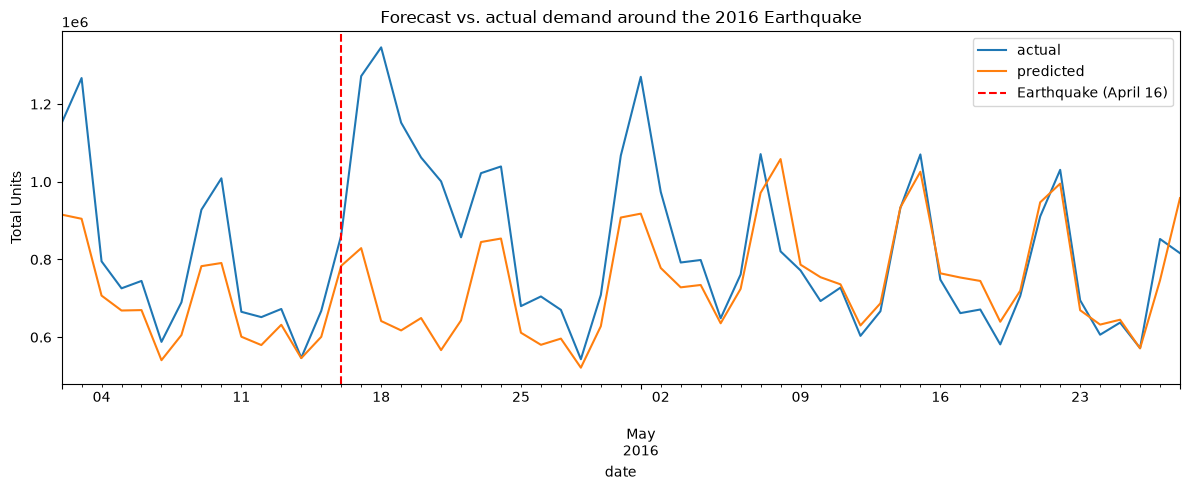

In [7]:
daily = test.groupby("date").agg(actual=("y_true", "sum"), predicted=("y_pred", "sum"))

ax = daily.plot(figsize=(12,5))
ax.axvline(QUAKE, color="red", ls="--",label="Earthquake (April 16)")
ax.set_title("Forecast vs. actual demand around the 2016 Earthquake")
ax.set_ylabel("Total Units")
ax.legend()

plt.tight_layout()
plt.show()

In [8]:
def split_section(d):
    if d < QUAKE: 
        return "1_pre"
    elif d<= QUAKE + pd.Timedelta(days=14):
        return "2_during"
    else:
        return "3_post"

test["section"] = test["date"].apply(split_section)

by_section = test.groupby("section").apply(
    lambda g: pd.Series({"RMSLE": rmsle(g.y_true, g.y_pred), "WAPE": wape(g.y_true, g.y_pred)}), include_groups=False
)

print(by_section.round(3))

          RMSLE   WAPE
section               
1_pre     0.448  0.192
2_during  0.517  0.306
3_post    0.493  0.217


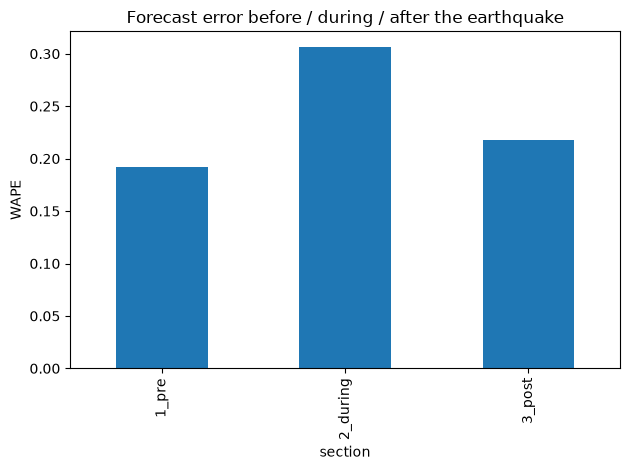

In [9]:
by_section["WAPE"].plot(kind="bar", title="Forecast error before / during / after the earthquake")
plt.ylabel("WAPE")
plt.tight_layout()
plt.show()

In [16]:
COASTAL = ["Manabi", "Esmeraldas", "Santa Elena", "Guayas"]
test["region"] = np.where(test["state"].isin(COASTAL), "Coastal (hit)", "Inland")

regional_wape = test[test["section"] == "2_during"].groupby("region").apply(
    lambda g: wape(g.y_true, g.y_pred), include_groups=False
)
print("WAPE by region during the earthquake:\n", regional_wape.round(3))

WAPE by region during the earthquake:
 region
Coastal (hit)    0.370
Inland           0.289
dtype: float64


In [17]:
fam = (test[test["section"]=="2_during"].groupby("family", observed=True).apply(
    lambda g: (g.y_true.sum()/max(g.y_pred.sum(),1)), include_groups=False
).sort_values(ascending=False).head(10))
print("\nTop product families by actual/predicted ratio during the earthquake:\n", fam.round(2))


Top product families by actual/predicted ratio during the earthquake:
 family
HOME APPLIANCES            2.48
PLAYERS AND ELECTRONICS    2.26
MAGAZINES                  2.15
BABY CARE                  1.70
HARDWARE                   1.64
HOME CARE                  1.60
PERSONAL CARE              1.56
GROCERY I                  1.53
PRODUCE                    1.51
LINGERIE                   1.48
dtype: float64


In [18]:
during = test[test["section"]=="2_during"]
fam_detail = during.groupby("family", observed=True).apply(
    lambda g: pd.Series({
        "actual": g.y_true.sum(),
        "predicted": g.y_pred.sum(),
        "ratio": g.y_true.sum()/max(g.y_pred.sum(),1),
        "excess_units": g.y_true.sum() - g.y_pred.sum()   # absolute surge, not just ratio
    }), include_groups=False
)
# rank by absolute excess demand, not ratio — surfaces where the surge actually mattered
print(fam_detail.sort_values("excess_units", ascending=False).head(10).round(1))

                  actual  predicted  ratio  excess_units
family                                                  
GROCERY I      4839686.5  3161832.9    1.5     1677853.6
BEVERAGES      3139915.0  2347591.7    1.3      792323.3
PRODUCE        1781078.0  1180144.9    1.5      600933.1
CLEANING       1031242.0   840245.3    1.2      190996.7
PERSONAL CARE   358492.0   230524.1    1.6      127967.9
HOME CARE       302560.0   189603.4    1.6      112956.6
BREAD/BAKERY    439860.3   384360.9    1.1       55499.4
POULTRY         315998.3   283974.5    1.1       32023.8
MEATS           288203.4   258845.2    1.1       29358.2
DAIRY           708512.0   684560.1    1.0       23951.9
